In [1]:
GPT_CONFIG_124M = {
    "vocab_size": 50257,       # Vocabulary size
    "context_length": 256,    # Context length
    "emb_dim": 768,            # Embedding dimension
    "n_heads": 12,             # Number of attention heads
    "n_layers": 12,            # Number of layers
    "drop_rate": 0.1,          # Dropout rate
    "qkv_bias": False          # Query-Key-Value bias
}

model_configs = {
    "gpt2-small (124M)": {"emb_dim": 768, "n_layers": 12, "n_heads": 12},
    "gpt2-medium (355M)": {"emb_dim": 1024, "n_layers": 24, "n_heads": 16},
    "gpt2-large (774M)": {"emb_dim": 1280, "n_layers": 36, "n_heads": 20},
    "gpt2-xl (1558M)": {"emb_dim": 1600, "n_layers": 48, "n_heads": 25},
}

In [2]:
import torch
import torch.nn as nn
import tiktoken
from torch.utils.data import Dataset, DataLoader

In [3]:
# from chapter 3

class MultiHeadAttention(nn.Module):
    def __init__(self, d_in, d_out, context_length, dropout, num_heads, qkv_bias=False):
        super().__init__()

        # Ensure that the output dimension can be evenly split across heads
        assert (d_out % num_heads == 0), "d_out must be divisible by num_heads"

        # Total output dimension of attention layer
        self.d_out = d_out

        # Number of attention heads
        self.num_heads = num_heads

        # Dimension handled by each head
        self.head_dim = d_out // num_heads

        # Linear projections to produce Query, Key, and Value vectors
        # Each token embedding is projected into d_out dimension
        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)

        # Final linear layer to mix the outputs of all heads
        self.out_proj = nn.Linear(d_out, d_out)

        # Dropout applied to attention weights (regularization)
        self.dropout = nn.Dropout(dropout)

        # Causal mask (upper triangular matrix)
        # Prevents tokens from attending to future tokens in autoregressive models
        self.register_buffer(
            "mask",
            torch.triu(torch.ones(context_length, context_length), diagonal=1)
        )

    def forward(self, x):

        # x shape: (batch_size, num_tokens, input_dimension)
        b, num_tokens, d_in = x.shape

        # Project input embeddings into query, key, and value vectors
        # Shape after projection: (batch_size, num_tokens, d_out)
        keys = self.W_key(x)
        queries = self.W_query(x)
        values = self.W_value(x)

        # Split each projection into multiple heads
        # New shape: (batch_size, num_tokens, num_heads, head_dim)
        keys = keys.view(b, num_tokens, self.num_heads, self.head_dim)
        values = values.view(b, num_tokens, self.num_heads, self.head_dim)
        queries = queries.view(b, num_tokens, self.num_heads, self.head_dim)

        # Move the head dimension before the token dimension
        # New shape: (batch_size, num_heads, num_tokens, head_dim)
        keys = keys.transpose(1, 2)
        values = values.transpose(1, 2)
        queries = queries.transpose(1, 2)

        # Compute attention scores using scaled dot-product attention
        # scores shape: (batch_size, num_heads, num_tokens, num_tokens)
        attn_scores = queries @ keys.transpose(2, 3)

        # Apply causal mask so tokens cannot attend to future tokens
        mask_bool = self.mask.bool()[:num_tokens, :num_tokens]
        attn_scores.masked_fill_(mask_bool, -torch.inf)

        # Scale scores by sqrt(head_dim) for numerical stability
        # Then convert scores to probabilities with softmax
        attn_weights = torch.softmax(
            attn_scores / keys.shape[-1]**0.5,
            dim=-1
        )

        # Apply dropout to attention weights
        attn_weights = self.dropout(attn_weights)

        # Compute weighted sum of value vectors
        # Result shape: (batch_size, num_heads, num_tokens, head_dim)
        context_vec = (attn_weights @ values).transpose(1, 2)

        # Merge all heads back together
        # Shape becomes: (batch_size, num_tokens, d_out)
        context_vec = context_vec.contiguous().view(b, num_tokens, self.d_out)

        # Final linear projection after concatenating heads
        context_vec = self.out_proj(context_vec)

        return context_vec

In [4]:
# from chapter 4

class LayerNorm(nn.Module):
    def __init__(self, emb_dim):
        super().__init__()

        # Small constant added to variance for numerical stability
        self.eps = 1e-5

        # Learnable scaling parameter (gamma in LayerNorm literature)
        # One value per embedding dimension
        self.scale = nn.Parameter(torch.ones(emb_dim))

        # Learnable shift parameter (beta)
        self.shift = nn.Parameter(torch.zeros(emb_dim))

    def forward(self, x):
        # Compute mean across embedding dimension
        # Shape: (batch, seq_len, 1)
        mean = x.mean(dim=-1, keepdim=True)

        # Compute variance across embedding dimension
        # unbiased=False matches typical LayerNorm implementation
        var = x.var(dim=-1, keepdim=True, unbiased=False)

        # Normalize input: (x - mean) / sqrt(var + eps)
        norm_x = (x - mean) / torch.sqrt(var + self.eps)

        # Apply learnable scale and shift
        return self.scale * norm_x + self.shift


class GELU(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x):
        # Gaussian Error Linear Unit activation
        # Smooth alternative to ReLU used in GPT/BERT
        # This is the tanh approximation of GELU
        return 0.5 * x * (
            1 + torch.tanh(
                torch.sqrt(torch.tensor(2.0 / torch.pi))
                * (x + 0.044715 * torch.pow(x, 3))
            )
        )


class FeedForward(nn.Module):
    def __init__(self, cfg):
        super().__init__()

        # Position-wise feed-forward network
        # Expands embedding dimension then projects back
        self.layers = nn.Sequential(

            # First linear layer expands dimension (typically 4x)
            nn.Linear(cfg["emb_dim"], 4 * cfg["emb_dim"]),

            # Non-linear activation
            GELU(),

            # Project back to original embedding size
            nn.Linear(4 * cfg["emb_dim"], cfg["emb_dim"]),
        )

    def forward(self, x):
        # Applies feed-forward network to each token independently
        return self.layers(x)


class TransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()

        # Multi-head self-attention layer
        self.att = MultiHeadAttention(
            d_in=cfg["emb_dim"],
            d_out=cfg["emb_dim"],
            context_length=cfg["context_length"],
            num_heads=cfg["n_heads"],
            dropout=cfg["drop_rate"],
            qkv_bias=cfg["qkv_bias"],
        )

        # Position-wise feed-forward network
        self.ff = FeedForward(cfg)

        # Layer normalization before attention
        self.norm1 = LayerNorm(cfg["emb_dim"])

        # Layer normalization before feed-forward
        self.norm2 = LayerNorm(cfg["emb_dim"])

        # Dropout applied to residual connections
        self.drop_shortcut = nn.Dropout(cfg["drop_rate"])

    def forward(self, x):

        # ---- Self-Attention Block ----

        # Save residual (shortcut) connection
        shortcut = x

        # Apply layer normalization
        x = self.norm1(x)

        # Apply multi-head self-attention
        x = self.att(x)

        # Apply dropout
        x = self.drop_shortcut(x)

        # Add residual connection
        x = x + shortcut


        # ---- Feed-Forward Block ----

        # Save residual connection again
        shortcut = x

        # Apply second normalization
        x = self.norm2(x)

        # Apply feed-forward network
        x = self.ff(x)

        # Apply dropout
        x = self.drop_shortcut(x)

        # Add residual connection
        x = x + shortcut

        return x


class GPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()

        # Token embedding layer
        # Converts token IDs into embedding vectors
        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])

        # Positional embedding layer
        # Adds information about token position in the sequence
        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])

        # Dropout applied to embeddings
        self.drop_emb = nn.Dropout(cfg["drop_rate"])

        # Stack of Transformer blocks
        self.trf_blocks = nn.Sequential(
            *[TransformerBlock(cfg) for _ in range(cfg["n_layers"])]
        )

        # Final layer normalization
        self.final_norm = LayerNorm(cfg["emb_dim"])

        # Output projection layer
        # Maps embeddings back to vocabulary logits
        self.out_head = nn.Linear(
            cfg["emb_dim"], cfg["vocab_size"], bias=False
        )

    def forward(self, in_idx):

        # Input shape: (batch_size, sequence_length)
        batch_size, seq_len = in_idx.shape

        # Convert token IDs into embeddings
        # Shape: (batch, seq_len, emb_dim)
        tok_embeds = self.tok_emb(in_idx)

        # Generate position indices (0...seq_len-1)
        # Then convert them to positional embeddings
        pos_embeds = self.pos_emb(
            torch.arange(seq_len, device=in_idx.device)
        )

        # Combine token and positional embeddings
        x = tok_embeds + pos_embeds

        # Apply dropout
        x = self.drop_emb(x)

        # Pass through transformer blocks
        x = self.trf_blocks(x)

        # Final normalization
        x = self.final_norm(x)

        # Project embeddings to vocabulary logits
        logits = self.out_head(x)

        return logits

In [5]:
def generate_text_simple(model, idx, max_new_tokens, context_size):
    # Loop to generate new tokens one by one
    for _ in range(max_new_tokens):

        # Take only the last `context_size` tokens as input to the model
        # This ensures the input does not exceed the model's maximum context length
        # Shape: (batch_size, context_size)
        idx_cond = idx[:, -context_size:]

        # Disable gradient calculation since we are doing inference (generation)
        with torch.no_grad():

            # Get model predictions (logits for each token in the vocabulary)
            # Shape: (batch_size, seq_len, vocab_size)
            logits = model(idx_cond)

        # Select logits corresponding to the last token in the sequence
        # This represents the prediction for the next token
        # Shape: (batch_size, vocab_size)
        logits = logits[:, -1, :]

        # Convert logits to probabilities using softmax
        probas = torch.softmax(logits, dim=-1)

        # Select the most probable next token (greedy decoding)
        # keepdim=True keeps shape as (batch_size, 1)
        idx_next = torch.argmax(probas, dim=-1, keepdim=True)

        # Append the predicted token to the existing sequence
        # New shape: (batch_size, current_seq_len + 1)
        idx = torch.cat((idx, idx_next), dim=1)

    # Return the full sequence including generated tokens
    return idx

In [6]:
def text_to_token_ids(text, tokenizer):
    encoded = tokenizer.encode(text, allowed_special={'<|endoftext|>'})
    encoded_tensor = torch.tensor(encoded).unsqueeze(0)   
    return encoded_tensor
    
def token_ids_to_text(token_ids, tokenizer):
    flat = token_ids.squeeze(0)               
    return tokenizer.decode(flat.tolist())

In [7]:
tokenizer = tiktoken.get_encoding("gpt2")
batch = []
txt1 = "Every effort moves"
txt2 = "I really like"

batch.append(text_to_token_ids(txt1, tokenizer))
batch.append(text_to_token_ids(txt2, tokenizer))
inp = torch.cat(batch, dim=0)

In [8]:
torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)
model.eval()
out = generate_text_simple(model=model, idx = inp, max_new_tokens = 10, context_size=GPT_CONFIG_124M["context_length"])

for idx in out:
    decoded_text = token_ids_to_text(idx, tokenizer)
    print(decoded_text)

Every effort moves Admir Sickomsaliationarsity assembledH bearinst slee
I really likefaith represents Abe WindsorFE sophisticationLab shave neighbour Been


## Above results are purely random. Now it needs training, but first code loss generator

In [9]:
inputs = torch.tensor([[16833, 3626, 6100],   # ["every effort moves",
               [40,    1107, 588]])   #  "I really like"]
targets = torch.tensor([[3626, 6100, 345  ],  # [" effort moves you",
                [1107, 588, 11311]])  #  " really like chocolate"]
with torch.no_grad():    
    logits = model(inputs)

In [10]:
# Manual Cross entropy

probas = torch.softmax(logits, dim=-1)    
token_ids = torch.argmax(probas, dim=-1, keepdim=True)

text_idx = 0
target_probas_1 = probas[text_idx, [0, 1, 2], targets[text_idx]]
text_idx = 1
target_probas_2 = probas[text_idx, [0, 1, 2], targets[text_idx]]

log_probas = torch.log(torch.cat((target_probas_1, target_probas_2)))
avg_log_probas = torch.mean(log_probas)
neg_avg_log_probas = avg_log_probas * -1
print(neg_avg_log_probas)

tensor(10.7940)


In [11]:
# PyTorch Cross entropy
logits_flat = logits.flatten(0, 1)
targets_flat = targets.flatten()
loss = torch.nn.functional.cross_entropy(logits_flat, targets_flat)
print(loss)

tensor(10.7940)


In [12]:
perplexity = torch.exp(loss)
print(perplexity)

tensor(48725.8203)


In [13]:
file_path = "the-verdict.txt"
with open(file_path, "r", encoding="utf-8") as file:
    text_data = file.read()

In [14]:
total_characters = len(text_data)
total_tokens = len(tokenizer.encode(text_data))
print("Characters:", total_characters)
print("Tokens:", total_tokens)

Characters: 20479
Tokens: 5145


In [15]:
train_ratio = 0.90
split_idx = int(train_ratio * total_characters)
train_data = text_data[:split_idx]
val_data = text_data[split_idx:]

In [16]:
# from chapter 2
class GPTDatasetV1(Dataset):
    def __init__(self, txt, tokenizer, max_length, stride):
        self.input_ids = []
        self.target_ids = []

        token_ids = tokenizer.encode(txt)
        for i in range(0, len(token_ids) - max_length, stride):
            input_chunk = token_ids[i:i+max_length]
            target_chunk = token_ids[i+1:i+max_length+1]
            self.input_ids.append(torch.tensor(input_chunk))
            self.target_ids.append(torch.tensor(target_chunk))
    def __len__(self):
        return len(self.input_ids)

    def __getitem__(self, idx):
        return self.input_ids[idx], self.target_ids[idx]
        
def create_dataloader_v1(txt, batch_size=4, max_length=256, stride=128, shuffle=True, drop_last=True, num_workers=0):
    tokenizer = tiktoken.get_encoding("gpt2")
    dataset = GPTDatasetV1(txt, tokenizer, max_length, stride)
    dataloader = DataLoader(
        dataset,
        batch_size = batch_size,
        shuffle=shuffle,
        drop_last=drop_last,
        num_workers=num_workers)

    return dataloader

In [17]:
torch.manual_seed(123)
train_loader = create_dataloader_v1(
    train_data,
    batch_size=2,
    max_length=GPT_CONFIG_124M["context_length"],
    stride=GPT_CONFIG_124M["context_length"],
    drop_last=True,
    shuffle=True,
    num_workers=0
)
val_loader = create_dataloader_v1(
    val_data,
    batch_size=2,
    max_length=GPT_CONFIG_124M["context_length"],
    stride=GPT_CONFIG_124M["context_length"],
    drop_last=False,
    shuffle=False,
    num_workers=0
)

In [18]:
print("Train loader:")
for x, y in train_loader:
    print(x.shape, y.shape)
print("\nValidation loader:")
for x, y in val_loader:
    print(x.shape, y.shape)

Train loader:
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])

Validation loader:
torch.Size([2, 256]) torch.Size([2, 256])


In [19]:
def calc_loss_batch(input_batch, target_batch, model, device):
    input_batch = input_batch.to(device)        
    target_batch = target_batch.to(device)      
    logits = model(input_batch)
    loss = torch.nn.functional.cross_entropy(
logits.flatten(0, 1), target_batch.flatten()
    )
    return loss

In [20]:
def calc_loss_loader(data_loader, model, device, num_batches=None):
    total_loss = 0.
    if len(data_loader) == 0:
        return float("nan")
    elif num_batches is None:
        num_batches = len(data_loader)    
    else:
        num_batches = min(num_batches, len(data_loader))  
    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i < num_batches:
            loss = calc_loss_batch(
                input_batch, target_batch, model, device
            )
            total_loss += loss.item()   
        else:
            break
    return total_loss / num_batches 

In [21]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("cuda" if torch.cuda.is_available() else "cpu")

cuda


In [22]:
model.to(device)  
with torch.no_grad():                                       
    train_loss = calc_loss_loader(train_loader, model, device)   
    val_loss = calc_loss_loader(val_loader, model, device)
print("Training loss:", train_loss)
print("Validation loss:", val_loss)

Training loss: 10.987583584255642
Validation loss: 10.98110580444336


## Now Start Training

In [23]:
def evaluate_model(model, train_loader, val_loader, device, eval_iter):
    model.eval() 
    with torch.no_grad():                             
        train_loss = calc_loss_loader(
            train_loader, model, device, num_batches=eval_iter
        )
        val_loss = calc_loss_loader(
            val_loader, model, device, num_batches=eval_iter
        )
    model.train()
    return train_loss, val_loss

In [24]:
def generate_and_print_sample(model, tokenizer, device, start_context):
    model.eval()
    context_size = model.pos_emb.weight.shape[0]
    encoded = text_to_token_ids(start_context, tokenizer).to(device)
    with torch.no_grad():
        token_ids = generate_text_simple(
            model=model, idx=encoded,
            max_new_tokens=50, context_size=context_size
        )
    decoded_text = token_ids_to_text(token_ids, tokenizer)
    print(decoded_text.replace("\n", " "))     
    model.train()

In [25]:
def train_model_simple(model, train_loader, val_loader,
               optimizer, device, num_epochs,
               eval_freq, eval_iter, start_context, tokenizer):
    train_losses, val_losses, track_tokens_seen = [], [], []   
    tokens_seen, global_step = 0, -1

    for epoch in range(num_epochs):   
        model.train()
        for input_batch, target_batch in train_loader:
            optimizer.zero_grad()  
            loss = calc_loss_batch(
                input_batch, target_batch, model, device
            )
            loss.backward()                    
            optimizer.step()                   
            tokens_seen += input_batch.numel()
            global_step += 1
     
            if global_step % eval_freq == 0:   
                train_loss, val_loss = evaluate_model(
                    model, train_loader, val_loader, device, eval_iter)
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                track_tokens_seen.append(tokens_seen)
                print(f"Ep {epoch+1} (Step {global_step:06d}): "
                      f"Train loss {train_loss:.3f}, "
                      f"Val loss {val_loss:.3f}"
                )
    
        generate_and_print_sample(                     
            model, tokenizer, device, start_context
        )
    return train_losses, val_losses, track_tokens_seen

In [26]:
torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)
model.to(device)
optimizer = torch.optim.AdamW(
     model.parameters(),          
    lr=0.0004, weight_decay=0.1
)
num_epochs = 10

train_losses, val_losses, tokens_seen = train_model_simple(
    model, train_loader, val_loader, optimizer, device,
    num_epochs=num_epochs, eval_freq=5, eval_iter=5,
    start_context="Every effort moves you", tokenizer=tokenizer
)

Ep 1 (Step 000000): Train loss 9.821, Val loss 9.931
Ep 1 (Step 000005): Train loss 8.069, Val loss 8.334
Every effort moves you,,,,,,,,,,,,,,.                                   
Ep 2 (Step 000010): Train loss 6.623, Val loss 7.049
Ep 2 (Step 000015): Train loss 6.046, Val loss 6.598
Every effort moves you, and,, and,,,,,,,,,.                                   
Ep 3 (Step 000020): Train loss 5.558, Val loss 6.503
Ep 3 (Step 000025): Train loss 5.471, Val loss 6.392
Every effort moves you, and to the to the of the to the, and I had. Gis, and I had, and, and, and, and I had, and, and, and, and, and, and, and, and, and,
Ep 4 (Step 000030): Train loss 4.995, Val loss 6.275
Ep 4 (Step 000035): Train loss 4.756, Val loss 6.289
Every effort moves you, and I had been the picture.                    "I"I the the donkey of the donkey the donkey of the picture and I had been a"I
Ep 5 (Step 000040): Train loss 4.113, Val loss 6.182
Every effort moves you know the "Oh, and he had to me--I me. "Oh, 

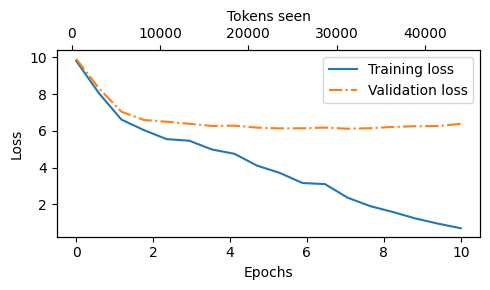

In [27]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
def plot_losses(epochs_seen, tokens_seen, train_losses, val_losses):
    fig, ax1 = plt.subplots(figsize=(5, 3))
    ax1.plot(epochs_seen, train_losses, label="Training loss")
    ax1.plot(
        epochs_seen, val_losses, linestyle="-.", label="Validation loss"
    )
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel("Loss")
    ax1.legend(loc="upper right")
    ax1.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax2 = ax1.twiny()                  
    ax2.plot(tokens_seen, train_losses, alpha=0)    
    ax2.set_xlabel("Tokens seen")
    fig.tight_layout()
    plt.show()

epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
plot_losses(epochs_tensor, tokens_seen, train_losses, val_losses)

In [28]:
model.eval()
tokenizer = tiktoken.get_encoding("gpt2")
token_ids = generate_text_simple(
    model=model,
    idx=text_to_token_ids("Every effort moves you", tokenizer).to(device),
    max_new_tokens=25,
    context_size=GPT_CONFIG_124M["context_length"]
)
print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 Every effort moves you?"

"Yes--quite insensible to the irony. She wanted him vindicated--and by me!"




In [29]:
vocab = { 
    "closer": 0,
    "every": 1, 
    "effort": 2, 
    "forward": 3,
    "inches": 4,
    "moves": 5, 
    "pizza": 6,
    "toward": 7,
    "you": 8,
} 
inverse_vocab = {v: k for k, v in vocab.items()}

In [30]:
next_token_logits = torch.tensor(
    [4.51, 0.89, -1.90, 6.75, 1.63, -1.62, -1.89, 6.28, 1.79]
)

In [31]:
def softmax_with_temperature(logits, temperature):
    scaled_logits = logits / temperature
    return torch.softmax(scaled_logits, dim=0)
probas = softmax_with_temperature(next_token_logits, 5)
print(probas)

tensor([0.1546, 0.0750, 0.0429, 0.2421, 0.0869, 0.0454, 0.0430, 0.2203, 0.0898])


In [32]:
next_token_id = torch.argmax(probas).item()
print(inverse_vocab[next_token_id])

forward


In [33]:
torch.manual_seed(123) 
next_token_id = torch.multinomial(probas, num_samples=1).item()
print(inverse_vocab[next_token_id])

every


In [34]:
def print_sampled_tokens(probas):
    torch.manual_seed(123)
    sample = [torch.multinomial(probas, num_samples=1).item()
            for i in range(1_000)]
    sampled_ids = torch.bincount(torch.tensor(sample))
    for i, freq in enumerate(sampled_ids):
        print(f"{freq} x {inverse_vocab[i]}")
print_sampled_tokens(probas)

165 x closer
75 x every
42 x effort
239 x forward
71 x inches
46 x moves
32 x pizza
227 x toward
103 x you


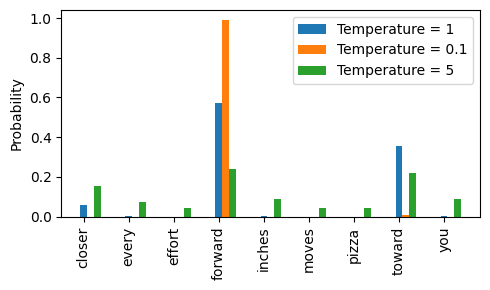

In [35]:
temperatures = [1, 0.1, 5]                                    
scaled_probas = [softmax_with_temperature(next_token_logits, T)
        for T in temperatures]
x = torch.arange(len(vocab))
bar_width = 0.15
fig, ax = plt.subplots(figsize=(5, 3))
for i, T in enumerate(temperatures):
    rects = ax.bar(x + i * bar_width, scaled_probas[i], 
           bar_width, label=f'Temperature = {T}')
ax.set_ylabel('Probability')
ax.set_xticks(x)
ax.set_xticklabels(vocab.keys(), rotation=90)
ax.legend()
plt.tight_layout()
plt.show()

### Exercise 5.1

In [37]:
temperatures = [0.01, 0.1, 1, 4, 16]                                    

for t in temperatures:
    probas = softmax_with_temperature(next_token_logits, t)
    print(f"temperature: {t}")
    print_sampled_tokens(probas)
    print(f"probability of pizza: {probas[6]}")
    print("")

temperature: 0.01
0 x closer
0 x every
0 x effort
1000 x forward
probability of pizza: 0.0

temperature: 0.1
0 x closer
0 x every
0 x effort
985 x forward
0 x inches
0 x moves
0 x pizza
15 x toward
probability of pizza: 2.971829782368292e-38

temperature: 1
73 x closer
0 x every
0 x effort
582 x forward
2 x inches
0 x moves
0 x pizza
343 x toward
probability of pizza: 0.00010120050137629732

temperature: 4
173 x closer
69 x every
31 x effort
268 x forward
63 x inches
34 x moves
23 x pizza
251 x toward
88 x you
probability of pizza: 0.03192311152815819

temperature: 16
128 x closer
109 x every
85 x effort
163 x forward
83 x inches
93 x moves
80 x pizza
148 x toward
111 x you
probability of pizza: 0.08631856739521027



In [38]:
top_k = 3
top_logits, top_pos = torch.topk(next_token_logits, top_k)
print("Top logits:", top_logits)
print("Top positions:", top_pos)

Top logits: tensor([6.7500, 6.2800, 4.5100])
Top positions: tensor([3, 7, 0])


In [39]:
new_logits = torch.where(
    condition=next_token_logits < top_logits[-1],   
    input=torch.tensor(float('-inf')),    
    other=next_token_logits    
)
print(new_logits)

tensor([4.5100,   -inf,   -inf, 6.7500,   -inf,   -inf,   -inf, 6.2800,   -inf])


In [40]:
topk_probas = torch.softmax(new_logits, dim=0)
print(topk_probas)

tensor([0.0615, 0.0000, 0.0000, 0.5775, 0.0000, 0.0000, 0.0000, 0.3610, 0.0000])


## Final form of Generating Text

In [41]:
def generate(model, idx, max_new_tokens, context_size,
     temperature=0.0, top_k=None, eos_id=None):
    for _ in range(max_new_tokens):           
        idx_cond = idx[:, -context_size:]
        with torch.no_grad():
            logits = model(idx_cond)
        logits = logits[:, -1, :]
        
        if top_k is not None:               
            top_logits, _ = torch.topk(logits, top_k)
            min_val = top_logits[:, -1]
            logits = torch.where(
                logits < min_val,
                torch.tensor(float('-inf')).to(logits.device),
                logits
            )
        if temperature > 0.0:                 
            logits = logits / temperature
            probs = torch.softmax(logits, dim=-1)
            idx_next = torch.multinomial(probs, num_samples=1)
        else:   
            idx_next = torch.argmax(logits, dim=-1, keepdim=True)
        if idx_next == eos_id:             
            break
        idx = torch.cat((idx, idx_next), dim=1)
    return idx

### Exercise 5.2

In [45]:
torch.manual_seed(123)
token_ids = generate(
    model=model,
    idx=text_to_token_ids("Every effort moves you", tokenizer).to(device),
    max_new_tokens=15,
    context_size=GPT_CONFIG_124M["context_length"],
    top_k=25,
    temperature=15
)
print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 Every effort moves you as though, or Florence me afterward ins geniused that dep Mrs of such


### Exercise 5.3

In [46]:
deterministic_token_ids = generate(
    model=model,
    idx=text_to_token_ids("Every effort moves you", tokenizer).to(device),
    max_new_tokens=15,
    context_size=GPT_CONFIG_124M["context_length"],
    top_k=None,
    temperature=0
)
print("Output text:\n", token_ids_to_text(deterministic_token_ids, tokenizer))

Output text:
 Every effort moves you?"

"Yes--quite insensible to the irony. She wanted


## Loading and Saving Model

In [42]:
torch.save(model.state_dict(), "model.pth")

In [43]:
model = GPTModel(GPT_CONFIG_124M)
model.load_state_dict(torch.load("model.pth", map_location=device))
model.eval()

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(256, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=False)
        (W_key): Linear(in_features=768, out_features=768, bias=False)
        (W_value): Linear(in_features=768, out_features=768, bias=False)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features

In [44]:
torch.save({
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    }, 
    "model_and_optimizer.pth"
)

### Exercise 5.4

In [65]:
checkpoint = torch.load("model_and_optimizer.pth", map_location=device)
model_imported = GPTModel(GPT_CONFIG_124M)
model_imported.load_state_dict(checkpoint["model_state_dict"])
model_imported.to(device)

optimizer_imported = torch.optim.AdamW(model_imported.parameters(), lr=5e-4, weight_decay=0.1)
optimizer_imported.load_state_dict(checkpoint["optimizer_state_dict"])
model_imported.train()

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(256, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=False)
        (W_key): Linear(in_features=768, out_features=768, bias=False)
        (W_value): Linear(in_features=768, out_features=768, bias=False)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features

In [66]:
num_epochs = 1

train_losses, val_losses, tokens_seen = train_model_simple(
    model_imported, train_loader, val_loader, optimizer_imported, device,
    num_epochs=num_epochs, eval_freq=5, eval_iter=5,
    start_context="Every effort moves you", tokenizer=tokenizer
)

Ep 1 (Step 000000): Train loss 0.550, Val loss 6.417
Ep 1 (Step 000005): Train loss 0.418, Val loss 6.439
Every effort moves you?"  "Yes--quite insensible to the irony. She wanted him vindicated--and by me!"  He laughed again, and threw back the window-curtains, moved aside a _jardiniere_ full of


## GPT Models

In [48]:
from gpt_download import download_and_load_gpt2
settings, params = download_and_load_gpt2(
    model_size="124M", models_dir="gpt2"
)

File already exists and is up-to-date: gpt2\124M\checkpoint
File already exists and is up-to-date: gpt2\124M\encoder.json
File already exists and is up-to-date: gpt2\124M\hparams.json
File already exists and is up-to-date: gpt2\124M\model.ckpt.data-00000-of-00001
File already exists and is up-to-date: gpt2\124M\model.ckpt.index
File already exists and is up-to-date: gpt2\124M\model.ckpt.meta
File already exists and is up-to-date: gpt2\124M\vocab.bpe


In [49]:
print("Settings:", settings)
print("Parameter dictionary keys:", params.keys())

Settings: {'n_vocab': 50257, 'n_ctx': 1024, 'n_embd': 768, 'n_head': 12, 'n_layer': 12}
Parameter dictionary keys: dict_keys(['blocks', 'b', 'g', 'wpe', 'wte'])


In [50]:
print(params["wte"])
print("Token embedding weight tensor dimensions:", params["wte"].shape)

[[-0.11010301 -0.03926672  0.03310751 ... -0.1363697   0.01506208
   0.04531523]
 [ 0.04034033 -0.04861503  0.04624869 ...  0.08605453  0.00253983
   0.04318958]
 [-0.12746179  0.04793796  0.18410145 ...  0.08991534 -0.12972379
  -0.08785918]
 ...
 [-0.04453601 -0.05483596  0.01225674 ...  0.10435229  0.09783269
  -0.06952604]
 [ 0.1860082   0.01665728  0.04611587 ... -0.09625227  0.07847701
  -0.02245961]
 [ 0.05135201 -0.02768905  0.0499369  ...  0.00704835  0.15519823
   0.12067825]]
Token embedding weight tensor dimensions: (50257, 768)


In [51]:
model_name = "gpt2-small (124M)"
NEW_CONFIG = GPT_CONFIG_124M.copy()
NEW_CONFIG.update(model_configs[model_name])
NEW_CONFIG.update({"context_length": 1024})
NEW_CONFIG.update({"qkv_bias": True})
print(NEW_CONFIG)

{'vocab_size': 50257, 'context_length': 1024, 'emb_dim': 768, 'n_heads': 12, 'n_layers': 12, 'drop_rate': 0.1, 'qkv_bias': True}


In [52]:
gpt = GPTModel(NEW_CONFIG)
gpt.eval()

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(1024, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=True)
        (W_key): Linear(in_features=768, out_features=768, bias=True)
        (W_value): Linear(in_features=768, out_features=768, bias=True)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=7

In [53]:
def assign(left, right):
    if left.shape != right.shape:
        raise ValueError(f"Shape mismatch. Left: {left.shape}, "
                  "Right: {right.shape}"
        )
    return torch.nn.Parameter(torch.tensor(right))

In [54]:
import numpy as np

def load_weights_into_gpt(gpt, params):          
    gpt.pos_emb.weight = assign(gpt.pos_emb.weight, params['wpe'])
    gpt.tok_emb.weight = assign(gpt.tok_emb.weight, params['wte'])
    
    for b in range(len(params["blocks"])):    
        q_w, k_w, v_w = np.split(                           
            (params["blocks"][b]["attn"]["c_attn"])["w"], 3, axis=-1)
        gpt.trf_blocks[b].att.W_query.weight = assign(
            gpt.trf_blocks[b].att.W_query.weight, q_w.T)
        gpt.trf_blocks[b].att.W_key.weight = assign(
            gpt.trf_blocks[b].att.W_key.weight, k_w.T)
        gpt.trf_blocks[b].att.W_value.weight = assign(
            gpt.trf_blocks[b].att.W_value.weight, v_w.T)
        
        q_b, k_b, v_b = np.split(
            (params["blocks"][b]["attn"]["c_attn"])["b"], 3, axis=-1)
        gpt.trf_blocks[b].att.W_query.bias = assign(
            gpt.trf_blocks[b].att.W_query.bias, q_b)
        gpt.trf_blocks[b].att.W_key.bias = assign(
            gpt.trf_blocks[b].att.W_key.bias, k_b)
        gpt.trf_blocks[b].att.W_value.bias = assign(
            gpt.trf_blocks[b].att.W_value.bias, v_b)
        
        gpt.trf_blocks[b].att.out_proj.weight = assign(
            gpt.trf_blocks[b].att.out_proj.weight, 
            params["blocks"][b]["attn"]["c_proj"]["w"].T)
        gpt.trf_blocks[b].att.out_proj.bias = assign(
            gpt.trf_blocks[b].att.out_proj.bias, 
            params["blocks"][b]["attn"]["c_proj"]["b"])
        
        gpt.trf_blocks[b].ff.layers[0].weight = assign(
            gpt.trf_blocks[b].ff.layers[0].weight, 
            params["blocks"][b]["mlp"]["c_fc"]["w"].T)
        gpt.trf_blocks[b].ff.layers[0].bias = assign(
            gpt.trf_blocks[b].ff.layers[0].bias, 
            params["blocks"][b]["mlp"]["c_fc"]["b"])
        gpt.trf_blocks[b].ff.layers[2].weight = assign(
            gpt.trf_blocks[b].ff.layers[2].weight, 
            params["blocks"][b]["mlp"]["c_proj"]["w"].T)
        gpt.trf_blocks[b].ff.layers[2].bias = assign(
            gpt.trf_blocks[b].ff.layers[2].bias, 
            params["blocks"][b]["mlp"]["c_proj"]["b"])
        
        gpt.trf_blocks[b].norm1.scale = assign(
            gpt.trf_blocks[b].norm1.scale, 
            params["blocks"][b]["ln_1"]["g"])
        gpt.trf_blocks[b].norm1.shift = assign(
            gpt.trf_blocks[b].norm1.shift, 
            params["blocks"][b]["ln_1"]["b"])
        gpt.trf_blocks[b].norm2.scale = assign(
            gpt.trf_blocks[b].norm2.scale, 
            params["blocks"][b]["ln_2"]["g"])
        gpt.trf_blocks[b].norm2.shift = assign(
            gpt.trf_blocks[b].norm2.shift, 
            params["blocks"][b]["ln_2"]["b"])

    gpt.final_norm.scale = assign(gpt.final_norm.scale, params["g"])
    gpt.final_norm.shift = assign(gpt.final_norm.shift, params["b"])
    gpt.out_head.weight = assign(gpt.out_head.weight, params["wte"])

In [55]:
load_weights_into_gpt(gpt, params)
gpt.to(device)

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(1024, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=True)
        (W_key): Linear(in_features=768, out_features=768, bias=True)
        (W_value): Linear(in_features=768, out_features=768, bias=True)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=7

In [56]:
torch.manual_seed(123)
token_ids = generate(
    model=gpt,
    idx=text_to_token_ids("The Capital of Georgia is", tokenizer).to(device),
    max_new_tokens=25,
    context_size=NEW_CONFIG["context_length"],
    top_k=50,
    temperature=1.5
)
print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 The Capital of Georgia is the place the capital can build infrastructure like a rail network. It's a very popular destination right after Georgia's economic prosperity.


In [57]:
torch.manual_seed(123)
token_ids = generate(
    model=gpt,
    idx=text_to_token_ids("Every effort moves you", tokenizer).to(device),
    max_new_tokens=25,
    context_size=NEW_CONFIG["context_length"],
    top_k=50,
    temperature=1.5
)
print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 Every effort moves you as far as the hand can go until the end of your turn unless something happens

This would remove you from a battle


### Exercise 5.5

In [64]:
train_loss = calc_loss_loader(train_loader, gpt, device)
val_loss = calc_loss_loader(val_loader, gpt, device)
print("Training loss:", train_loss)
print("Validation loss:", val_loss)

Training loss: 3.7547629674275718
Validation loss: 3.559633255004883


### Exercise 5.2

In [62]:
token_ids = generate(
    model=gpt,
    idx=text_to_token_ids("Every effort moves you", tokenizer).to(device),
    max_new_tokens=15,
    context_size=GPT_CONFIG_124M["context_length"],
    top_k=5,
    temperature=15
)
print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 Every effort moves you to the edge, but the only place where that will be possible is with


In [63]:
token_ids = generate(
    model=gpt,
    idx=text_to_token_ids("Every effort moves you", tokenizer).to(device),
    max_new_tokens=15,
    context_size=GPT_CONFIG_124M["context_length"],
    top_k=1,
    temperature=0
)
print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 Every effort moves you forward.

The first step is to understand the importance of your work


### Exercise 5.6

In [46]:
from gpt_download import download_and_load_gpt2
settings_xl, params_xl = download_and_load_gpt2(
    model_size="1558M", models_dir="gpt2"
)

File already exists and is up-to-date: gpt2\1558M\checkpoint
File already exists and is up-to-date: gpt2\1558M\encoder.json
File already exists and is up-to-date: gpt2\1558M\hparams.json
File already exists and is up-to-date: gpt2\1558M\model.ckpt.data-00000-of-00001
File already exists and is up-to-date: gpt2\1558M\model.ckpt.index
File already exists and is up-to-date: gpt2\1558M\model.ckpt.meta
File already exists and is up-to-date: gpt2\1558M\vocab.bpe


In [47]:
model_name = "gpt2-xl (1558M)"
BIG_CONFIG = GPT_CONFIG_124M.copy()
BIG_CONFIG.update(model_configs[model_name])
BIG_CONFIG.update({"context_length": 1024})
BIG_CONFIG.update({"qkv_bias": True})
print(BIG_CONFIG)

{'vocab_size': 50257, 'context_length': 1024, 'emb_dim': 1600, 'n_heads': 25, 'n_layers': 48, 'drop_rate': 0.1, 'qkv_bias': True}


In [48]:
gptxl = GPTModel(BIG_CONFIG)
gptxl.eval()

GPTModel(
  (tok_emb): Embedding(50257, 1600)
  (pos_emb): Embedding(1024, 1600)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=1600, out_features=1600, bias=True)
        (W_key): Linear(in_features=1600, out_features=1600, bias=True)
        (W_value): Linear(in_features=1600, out_features=1600, bias=True)
        (out_proj): Linear(in_features=1600, out_features=1600, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=1600, out_features=6400, bias=True)
          (1): GELU()
          (2): Linear(in_features=6400, out_features=1600, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(i

In [49]:
load_weights_into_gpt(gptxl, params_xl)

In [50]:
gptxl.to(device)

GPTModel(
  (tok_emb): Embedding(50257, 1600)
  (pos_emb): Embedding(1024, 1600)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=1600, out_features=1600, bias=True)
        (W_key): Linear(in_features=1600, out_features=1600, bias=True)
        (W_value): Linear(in_features=1600, out_features=1600, bias=True)
        (out_proj): Linear(in_features=1600, out_features=1600, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=1600, out_features=6400, bias=True)
          (1): GELU()
          (2): Linear(in_features=6400, out_features=1600, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(i

In [52]:
token_ids = generate(
    model=gptxl,
    idx=text_to_token_ids("The Capital of Georgia is", tokenizer).to(device),
    max_new_tokens=25,
    context_size=BIG_CONFIG["context_length"],
    top_k=50,
    temperature=1.5
)
print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 The Capital of Georgia is the place the capital can use because it was founded within Georgian territory but does not belong to it. As you may observe,


In [53]:
token_ids = generate(
    model=gptxl,
    idx=text_to_token_ids("Every effort moves you", tokenizer).to(device),
    max_new_tokens=25,
    context_size=BIG_CONFIG["context_length"],
    top_k=50,
    temperature=1.5
)
print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 Every effort moves you further to where you do not actually want to grow; you are still too much of an outsider. This has been demonstrated clearly
